# 01 — EDA and Feature Engineering (YOLOv10 dataset)

In [1]:
from pathlib import Path
import os
import sys

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (CURRENT, *CURRENT.parents) if (path / "src").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Project root табылмады. Notebook-ты project папкасының ішінен ашыңыз."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", sys.executable)


PROJECT_ROOT: C:\Users\Ansagan\Downloads\smart_vision_final_project_laptop_cpu
Python: c:\Users\Ansagan\venvs\ml-yolo-cpu\Scripts\python.exe


EDA және feature engineering көлемі үлкен **YOLOv10 dataset** бойынша орындалады.

In [2]:
import matplotlib.pyplot as plt
from IPython.display import display

from src.config import EDA_DIR, analysis_data_yaml
from src.yolo_dataset_utils import (
    build_image_and_box_tables,
    dataset_diagnostics,
    save_tables,
)

DATA_YAML = analysis_data_yaml()
print("EDA dataset:", DATA_YAML)
display(dataset_diagnostics(DATA_YAML))


c:\Users\Ansagan\venvs\ml-yolo-cpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EDA dataset: C:\Users\Ansagan\Downloads\smart_vision_final_project_laptop_cpu\outputs\runtime\yolov10\data_runtime.yaml


,split,resolved_path,path_exists,images,label_files,objects,missing_label_examples
0,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,True,3752,3752,4366,
1,val,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,True,938,938,1047,
2,test,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,True,938,938,1047,


In [3]:
# None = барлық сурет. Жылдам smoke test үшін 100 қойыңыз.
MAX_IMAGES_PER_SPLIT = 300

image_df, box_df, dataset_config = build_image_and_box_tables(
    data_yaml=DATA_YAML,
    include_image_features=True,
    max_images_per_split=MAX_IMAGES_PER_SPLIT,
    show_progress=True,
    splits=("train", "val"),
)
if image_df.empty:
    raise ValueError("Image table бос. 00 notebook диагностикасын тексеріңіз.")
if box_df.empty:
    raise ValueError("Bounding-box table бос. labels папкаларын тексеріңіз.")

save_tables(image_df, box_df, EDA_DIR)
print("Image table:", image_df.shape)
print("Box table:", box_df.shape)
display(image_df.head())
display(box_df.head())


val EDA: 100%|██████████| 300/300 [00:05<00:00, 57.57image/s]

Image table: (600, 9)
Box table: (600, 13)


,split,image_path,label_path,width,height,brightness,contrast,objects_count,has_label
0,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,640,640,145.605337,79.658980,1,True
1,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,640,640,140.041506,76.038840,1,True
2,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,640,640,116.388030,82.077053,1,True
3,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,640,640,149.422534,72.973059,1,True
4,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,640,640,105.577725,72.972052,1,True


,split,image_path,label_path,class_id,class_name,x_center,y_center,bbox_w,bbox_h,bbox_area,bbox_aspect_ratio,brightness,contrast
0,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,2,basty,0.252344,0.535156,0.235937,0.314063,0.074099,0.751241,145.605337,79.658980
1,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,2,basty,0.405469,0.188281,0.282813,0.373437,0.105613,0.757325,140.041506,76.038840
2,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,2,basty,0.834375,0.204687,0.253125,0.340625,0.086221,0.743119,116.388030,82.077053
3,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,2,basty,0.443750,0.805469,0.256250,0.342187,0.087685,0.748860,149.422534,72.973059
4,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,2,basty,0.440625,0.203906,0.256250,0.335938,0.086084,0.762790,105.577725,72.972052


In [4]:
split_summary = (
    image_df.groupby("split")
    .agg(
        images=("image_path", "count"),
        labeled_images=("has_label", "sum"),
        total_objects=("objects_count", "sum"),
        average_objects=("objects_count", "mean"),
        average_brightness=("brightness", "mean"),
        average_contrast=("contrast", "mean"),
    )
    .reset_index()
)
display(split_summary)


,split,images,labeled_images,total_objects,average_objects,average_brightness,average_contrast
0,train,300,300,300,1.0,128.553696,76.686569
1,val,300,300,300,1.0,125.553215,76.257709


In [5]:
class_summary = (
    box_df.groupby(["split", "class_id", "class_name"])
    .size()
    .reset_index(name="objects")
    .sort_values(["split", "objects"], ascending=[True, False])
)
display(class_summary)


,split,class_id,class_name,objects
1,train,14,belgi10,152
0,train,2,basty,148
4,val,15,belgi11,59
3,val,14,belgi10,54
5,val,16,belgi12,53
6,val,17,belgi13,53
7,val,18,belgi14,49
2,val,2,basty,32


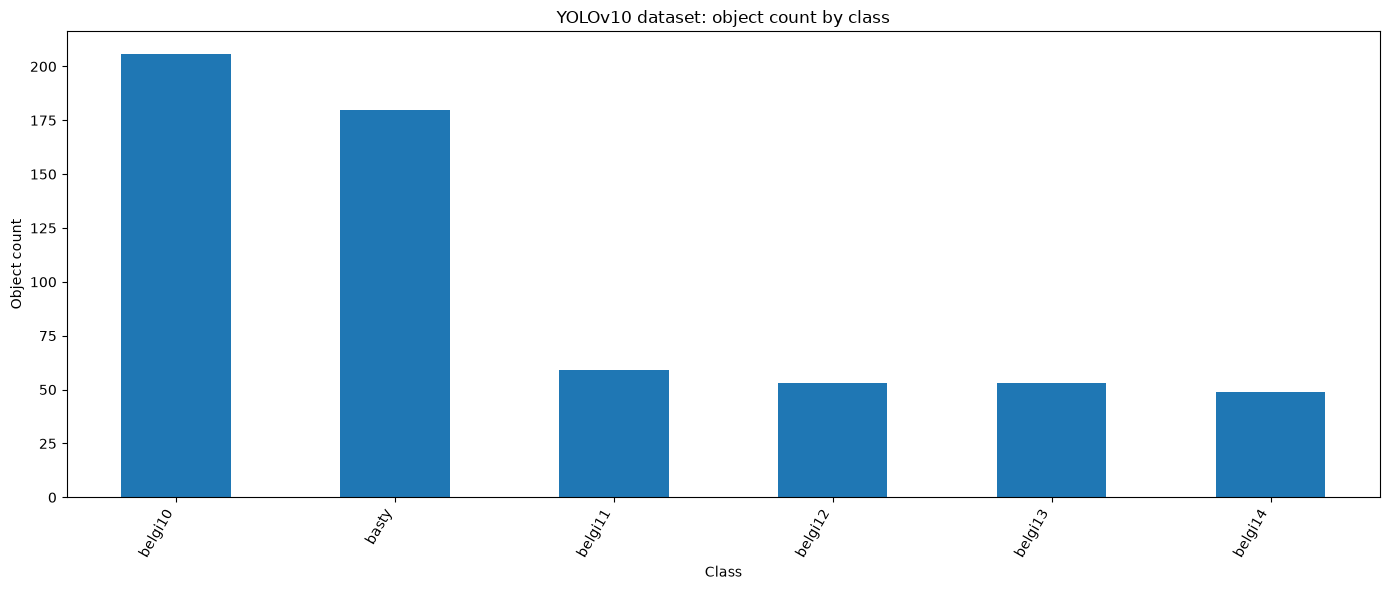

In [6]:
class_counts = box_df["class_name"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(14, 6))
class_counts.plot(kind="bar")
plt.title("YOLOv10 dataset: object count by class")
plt.xlabel("Class")
plt.ylabel("Object count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


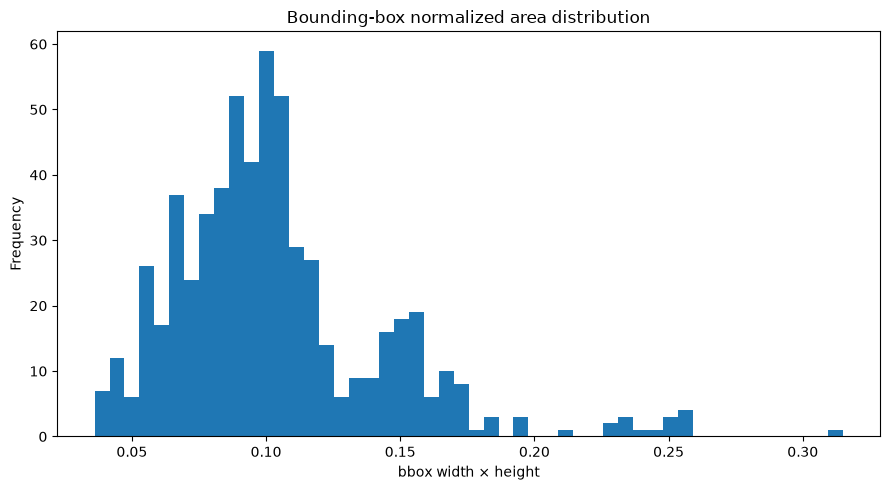

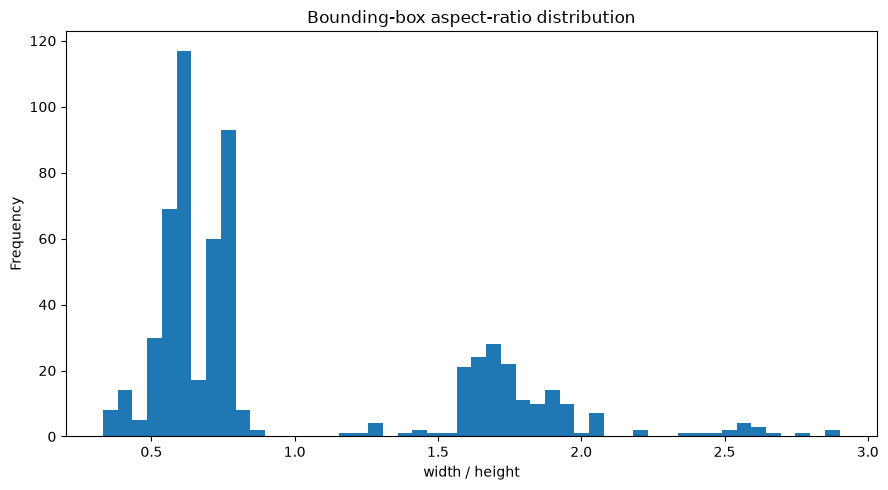

In [7]:
plt.figure(figsize=(9, 5))
box_df["bbox_area"].plot(kind="hist", bins=50)
plt.title("Bounding-box normalized area distribution")
plt.xlabel("bbox width × height")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
box_df["bbox_aspect_ratio"].replace([float("inf"), float("-inf")], float("nan")).dropna().clip(upper=10).plot(kind="hist", bins=50)
plt.title("Bounding-box aspect-ratio distribution")
plt.xlabel("width / height")
plt.tight_layout()
plt.show()


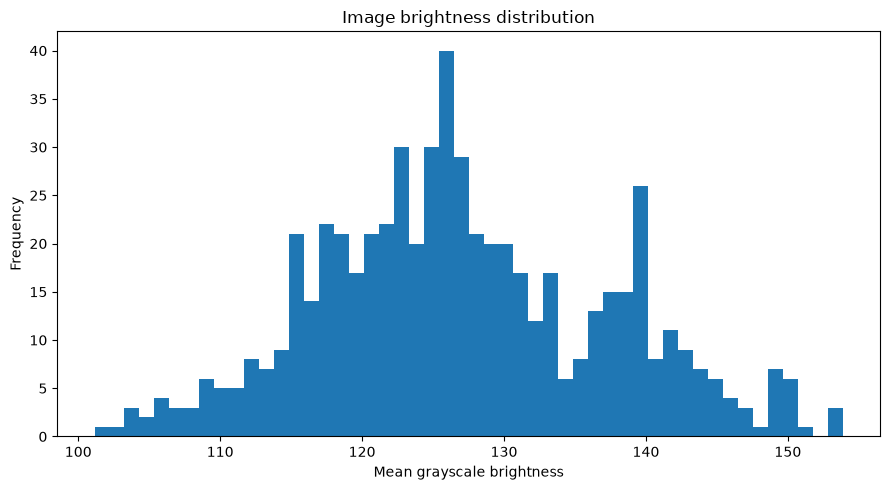

Class imbalance ratio: 4.204
Feature engineering: bbox_area, bbox_aspect_ratio, brightness, contrast, objects_count


In [8]:
plt.figure(figsize=(9, 5))
image_df["brightness"].dropna().plot(kind="hist", bins=50)
plt.title("Image brightness distribution")
plt.xlabel("Mean grayscale brightness")
plt.tight_layout()
plt.show()

imbalance_ratio = float(class_counts.max() / class_counts.min())
print("Class imbalance ratio:", round(imbalance_ratio, 3))
print("Feature engineering: bbox_area, bbox_aspect_ratio, brightness, contrast, objects_count")
